# CIFAR-10 图像分类


In [1]:
import torch
import torchvision
from torch import nn
import util
import shutil
import pandas as pd
import math
import os
import kagglehub
from pathlib import Path
import collections

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


加载数据


In [2]:
data_dir = Path('./data/cifar-10')
label_file = data_dir/'trainLabels.csv'
def read_csv_labels(fname: str):
    with open(fname, 'r') as f:
        lines = f.readlines()[1:]  # 去掉表头
    tokens = [l.rstrip().split(',') for l in lines]
    return dict((name, label) for name, label in tokens)
read_csv_labels(label_file)

{'1': 'frog',
 '2': 'truck',
 '3': 'truck',
 '4': 'deer',
 '5': 'automobile',
 '6': 'automobile',
 '7': 'bird',
 '8': 'horse',
 '9': 'ship',
 '10': 'cat',
 '11': 'deer',
 '12': 'horse',
 '13': 'horse',
 '14': 'bird',
 '15': 'truck',
 '16': 'truck',
 '17': 'truck',
 '18': 'cat',
 '19': 'bird',
 '20': 'frog',
 '21': 'deer',
 '22': 'cat',
 '23': 'frog',
 '24': 'frog',
 '25': 'bird',
 '26': 'frog',
 '27': 'cat',
 '28': 'dog',
 '29': 'deer',
 '30': 'airplane',
 '31': 'airplane',
 '32': 'truck',
 '33': 'automobile',
 '34': 'cat',
 '35': 'deer',
 '36': 'airplane',
 '37': 'cat',
 '38': 'horse',
 '39': 'cat',
 '40': 'cat',
 '41': 'dog',
 '42': 'bird',
 '43': 'bird',
 '44': 'horse',
 '45': 'automobile',
 '46': 'automobile',
 '47': 'automobile',
 '48': 'bird',
 '49': 'bird',
 '50': 'airplane',
 '51': 'truck',
 '52': 'dog',
 '53': 'horse',
 '54': 'truck',
 '55': 'bird',
 '56': 'bird',
 '57': 'dog',
 '58': 'bird',
 '59': 'deer',
 '60': 'cat',
 '61': 'automobile',
 '62': 'automobile',
 '63': 'ship',

分离验证集


In [3]:
new_root = 'train_valid_test'
def copyfile(filename, target_dir: Path):
    target_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(filename, target_dir)

def reorg_train_valid(data_dir: Path, labels: dict, valid_ratio: float):
    n = collections.Counter(labels.values()).most_common()[-1][1]
    n_valid_per_label = max(1, math.floor(n * valid_ratio))
    label_count = {}
    for train_file in os.listdir(data_dir/'train'):
        label = labels[train_file.split('.')[0]]
        fname = data_dir/'train'/train_file
        if label not in label_count or label_count[label] < n_valid_per_label:
            copyfile(fname, data_dir/new_root/'valid'/label)
            label_count[label] = label_count.get(label, 0) + 1
        else:
            copyfile(fname, data_dir/new_root/'train'/label)
    return n_valid_per_label

def reorg_test(data_dir: Path):
    for test_file in os.listdir(data_dir/'test'):
        copyfile(data_dir/'test'/test_file, data_dir/new_root/'test'/'unknown')

def reorg_cifar10_data(data_dir: Path, valid_ratio: float):
    labels = read_csv_labels(label_file)
    reorg_train_valid(data_dir, labels, valid_ratio)
    reorg_test(data_dir)

In [4]:
reorg_cifar10_data(data_dir, valid_ratio=0.1)

图像增广


In [12]:
normalize = torchvision.transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                                             std=[0.2023, 0.1994, 0.2010])
train_aug = torchvision.transforms.Compose([
    torchvision.transforms.Resize(40), # 放大到 40x40
    torchvision.transforms.RandomResizedCrop(32, scale=(0.64, 1.0), ratio=(1.0, 1.0)), # 随机裁剪回 32x32
    torchvision.transforms.RandomHorizontalFlip(), # 随机水平翻转
    torchvision.transforms.ToTensor(), # 转为张量
    normalize
])
test_aug = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32), # 调整图像大小为 32x32
    torchvision.transforms.ToTensor(), # 转为张量
    normalize
])

读取


In [13]:
# 带增强
train_ds = torchvision.datasets.ImageFolder(data_dir/new_root/'train', transform=train_aug)
train_valid_ds = torchvision.datasets.ImageFolder(data_dir/new_root/'valid', transform=train_aug)
# 不带增强
valid_ds = torchvision.datasets.ImageFolder(data_dir/new_root/'valid', transform=test_aug)
test_ds = torchvision.datasets.ImageFolder(data_dir/new_root/'test', transform=test_aug)

In [14]:
batch_size = 256
train_iter, train_valid_iter, valid_iter, test_iter = util.data.get_dataloader(
    train_ds, train_valid_ds, valid_ds, test_ds,
    batch_size=batch_size
)

模型

In [18]:
def get_pretrained_net():
    net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    net.fc = nn.Linear(net.fc.in_features, 10)
    nn.init.xavier_normal_(net.fc.weight)
    return net

def get_scratch_net():
    return util.model.resnet18(num_classes=10, in_channels=3)

loss = nn.CrossEntropyLoss(reduction="none")

训练

In [19]:
def train(net,
          train_iter, valid_iter,
          num_epochs,
          lr, wd,
          devices,
          lr_period, lr_decay,
          finetune=True):
    if finetune:
        trainer = torch.optim.Adam([
            {'params': [param for name, param in net.named_parameters() if name not in ['fc.weight', 'fc.bias']]},
            {'params': net.fc.parameters(), 'lr': lr * 10}
        ], lr=lr, weight_decay=wd)
    else:
        trainer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, step_size=lr_period, gamma=lr_decay)
    num_batches = len(train_iter)
    timer = util.Timer()
    legend = ['train loss', 'train acc']
    if valid_iter is not None:
        legend.append('valid acc')
    animator = util.Animator(xlabel='epoch', xlim=[1, num_epochs], legend=legend, ylim=[0.2, 1])
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        net.train()
        metric = util.Accumulator(3)
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            l, acc = util.train.train_batch_ch13(net, X, y, loss, trainer, devices)
            metric.add(l, acc, y.shape[0])
            timer.stop()
            # 每个 epoch 画两次
            if (i + 1) % (num_batches // 2) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[2], None))
        if valid_iter is not None:
            valid_acc = util.train.evaluate_accuracy_gpu(net, valid_iter)
            animator.add(epoch + 1, (None, None, valid_acc))
        scheduler.step()
    measures = (f'train loss {metric[0] / metric[2]:.3f}, ',
                f'train acc {metric[1] / metric[2]:.3f}')
    if valid_iter is not None:
        measures += (f'valid acc {valid_acc:.3f}, ',)
    print(measures + (f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}',))

('train loss 0.006, ', 'train acc 0.998', 'valid acc 0.969, ', "9931.7 examples/sec on [device(type='cuda', index=0)]")


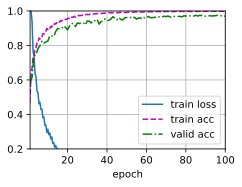

In [ ]:
devices = util.try_all_gpus()
net = get_scratch_net()
num_epochs = 100
lr = 2e-4
wd = 5e-4
lr_period = 4 # 每隔 4 个 epoch 学习率衰减一次
lr_decay = 0.9 # 每次衰减为原来的 0.9 倍
train(net,
      train_iter, valid_iter,
      num_epochs=num_epochs,
      lr=lr, wd=wd,
      devices=devices,
      lr_period=lr_period, lr_decay=lr_decay,
      finetune=False)

预测


In [ ]:
def predict(net, test_iter):
    preds = []
    for X, _ in test_iter:
        y_hat = net(X.to(devices[0]))
        y_hat = y_hat.argmax(axis=1)
        preds.extend(y_hat.type(torch.int32).cpu().numpy())
        if len(preds) % 2000 == 0:
            print(f'Processed {len(preds)} examples, {len(test_iter.dataset)-len(preds)} left')
    sorted_ids = list(range(1, len(test_ds) + 1))
    sorted_ids.sort(key=lambda x: str(x))
    df = pd.DataFrame({'id': sorted_ids, 'label': preds})
    df['label'] = df['label'].map(lambda x: train_valid_ds.classes[x])
    return df

pred = predict(net, test_iter)
pred.to_csv(data_dir/'submission.csv', index=False)